# 1. Setup

In [1]:
import json
import logging
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import joblib
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
import optuna
import shap

log = logging.getLogger("mlp")
logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s [%(levelname)s] %(message)s",
                    datefmt="%H:%M:%S")
logging.getLogger("shap").setLevel(logging.WARNING)
logging.getLogger("matplotlib").setLevel(logging.WARNING)


SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
log.info(f"Device: {DEVICE}")
if DEVICE == "cuda":
    log.info(f"GPU: {torch.cuda.get_device_name(0)}")

ROOT = Path.cwd()
DATA = ROOT / "data" / "data_cleaned.csv"
MODEL_DIR = ROOT / "models"
FIG_DIR = ROOT / "outputs" / "figures"
RESULTS = ROOT / "outputs" / "mlp_metrics.json"

for p in (MODEL_DIR, FIG_DIR):
    p.mkdir(parents=True, exist_ok=True)

N_TRIALS = 50
N_FOLDS = 5
MAX_EPOCHS = 200
PATIENCE = 30
BATCH_SIZE = 1024
SHAP_BG = 100
SHAP_EVAL = 200


SEVERITY_ORDER = ["Slight Injury", "Serious Injury", "Fatal injury"]
SEVERITY_COLORS = {
    "Slight Injury": "#2ca02c",
    "Serious Injury": "#f1c40f",
    "Fatal injury": "#d62728",
}
SEVERITY_PALETTE = [SEVERITY_COLORS[s] for s in SEVERITY_ORDER]
SEV_SHORT = ["Slight", "Serious", "Fatal"]



/home/minhubuntu/projects/crash-severity-tabnet-stacking/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
15:31:20 [INFO] Device: cuda
15:31:20 [INFO] GPU: NVIDIA GeForce RTX 4060 Laptop GPU


# 2 Helpers

In [2]:
def define_features(df: pd.DataFrame):
    """Return (cat_cols, num_cols). The four columns with `_ord` versions are
    dropped from cat_cols because their ordinal numeric counterpart already
    captures the rank ordering, and including both would be redundant."""
    drop_originals_with_ord = [
        "Age_band_of_driver", "Driving_experience",
        "Service_year_of_vehicle", "Educational_level",
    ]
    target_cols = ["Accident_severity", "Severity_code"]
    cat_cols = [c for c in df.select_dtypes(include="object").columns
                if c not in target_cols + drop_originals_with_ord]
    num_cols = [c for c in df.select_dtypes(include=["int64", "float64"]).columns
                if c not in target_cols]
    return cat_cols, num_cols


def encode_mlp(df, cat_cols, num_cols, encoder=None, scaler=None, fit=True):
    """Encode inputs for an entity-embedding MLP.

    Categorical columns stay separate as integer indices for nn.Embedding.
    Numeric columns are standardized. Encoder/scaler are fit on train only.
    """
    cat = df[cat_cols].astype(str).values
    num = df[num_cols].astype(float).values

    if fit:
        encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
        cat_enc = encoder.fit_transform(cat)
        scaler = StandardScaler()
        num_sc = scaler.fit_transform(num)
    else:
        cat_enc = encoder.transform(cat)
        num_sc = scaler.transform(num)

    cat_enc = (cat_enc + 1).astype(np.int64)
    num_sc = num_sc.astype(np.float32)
    return cat_enc, num_sc, encoder, scaler


def get_embedding_dims(encoder):
    """Return (cardinality, embedding_dim) pairs for MLP entity embeddings.

    Cardinality includes index 0, reserved for unknown categories.
    """
    embedding_dims = []
    for categories in encoder.categories_:
        cardinality = len(categories) + 1
        emb_dim = min(50, (cardinality + 1) // 2)
        embedding_dims.append((cardinality, emb_dim))
    return embedding_dims


In [ ]:
def metric_block(y_true, y_pred, y_proba, label=""):
    """Compute and pretty-print the full metric panel for a single test set."""
    out = {
        "accuracy":         accuracy_score(y_true, y_pred),
        "precision_macro":  precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro":     recall_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_macro":         f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_weighted":      f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "roc_auc_ovr":      roc_auc_score(y_true, y_proba, multi_class="ovr", average="macro"),
    }
    print(f"=== {label} ===")
    for k, v in out.items():
        print(f"  {k:<18s} {v:.4f}")
    print("\n  classification report:")
    print(classification_report(y_true, y_pred, target_names=SEV_SHORT, zero_division=0))
    return out


In [27]:
def plot_confusion(cm, title, save_path=None):
    fig, ax = plt.subplots(figsize=(5.5, 4.5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(3)); ax.set_yticks(range(3))
    ax.set_xticklabels(SEV_SHORT); ax.set_yticklabels(SEV_SHORT)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, int(cm[i, j]), ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() * 0.5 else "black")
    plt.colorbar(im, ax=ax, fraction=0.04)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150)
    plt.show()


# 3 Load data and split

In [4]:
df = pd.read_csv(DATA)
cat_cols, num_cols = define_features(df)
feature_names = cat_cols + num_cols

log.info(f"data shape: {df.shape}")
log.info(f"cat features ({len(cat_cols)}): {cat_cols}")
log.info(f"num features ({len(num_cols)}): {num_cols}")

y = df["Severity_code"].values
print(pd.Series(y).map(dict(enumerate(SEV_SHORT))).value_counts())


/tmp/ipykernel_89862/443279163.py:10: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = [c for c in df.select_dtypes(include="object").columns
15:31:27 [INFO] data shape: (12316, 32)
15:31:27 [INFO] cat features (17): ['Day_of_week', 'Sex_of_driver', 'Vehicle_driver_relation', 'Type_of_vehicle', 'Owner_of_vehicle', 'Area_accident_occured', 'Lanes_or_Medians', 'Road_allignment', 'Types_of_Junction', 'Road_surface_type', 'Road_surface_conditions', 'Light_conditions', 'Weather_conditions', 'Type_of_collision', 'Vehicle_movement', 'Cause_of_accident', 'TimeOfDay']
15:31

Slight     10415
Serious     1743
Fatal        158
Name: count, dtype: int64


In [5]:
df_trainval, df_test = train_test_split(
    df, test_size=0.15, stratify=y, random_state=SEED
)
df_train, df_val = train_test_split(
    df_trainval, test_size=0.1765,
    stratify=df_trainval["Severity_code"].values, random_state=SEED
)
y_train = df_train["Severity_code"].values
y_val = df_val["Severity_code"].values
y_test = df_test["Severity_code"].values


cat_train, num_train, encoder, scaler = encode_mlp(
    df_train, cat_cols, num_cols, fit=True
)
cat_val, num_val, _, _ = encode_mlp(
    df_val, cat_cols, num_cols, encoder=encoder, scaler=scaler, fit=False
)
cat_test, num_test, _, _ = encode_mlp(
    df_test, cat_cols, num_cols, encoder=encoder, scaler=scaler, fit=False
)
embedding_dims = get_embedding_dims(encoder)
raw_feature_dim = cat_train.shape[1] + num_train.shape[1]
embedding_input_dim = sum(emb_dim for _, emb_dim in embedding_dims)
mlp_input_dim = embedding_input_dim + num_train.shape[1]

log.info(f"split sizes: train={len(df_train)}, val={len(df_val)}, test={len(df_test)}")
log.info(f"categorical tensor shape: {cat_train.shape}")
log.info(f"numeric tensor shape: {num_train.shape}")
log.info(f"raw feature dim: {raw_feature_dim}")
log.info(f"embedding input dim: {embedding_input_dim}")
log.info(f"MLP input dim: {mlp_input_dim}")
log.info(f"embedding dims: {embedding_dims}")

15:31:30 [INFO] split sizes: train=8620, val=1848, test=1848
15:31:30 [INFO] categorical tensor shape: (8620, 17)
15:31:30 [INFO] numeric tensor shape: (8620, 9)
15:31:30 [INFO] raw feature dim: 26
15:31:30 [INFO] embedding input dim: 85
15:31:30 [INFO] MLP input dim: 94
15:31:30 [INFO] embedding dims: [(8, 4), (4, 2), (5, 3), (19, 10), (6, 3), (13, 7), (8, 4), (11, 6), (9, 5), (7, 4), (4, 2), (5, 3), (10, 5), (11, 6), (14, 7), (21, 11), (5, 3)]


# 4 SMOTE and PyTorch datasets


In [6]:
def apply_smote_mlp(X_cat, X_num, y, embedding_dims):
    """Apply SMOTE to encoded train data only, then restore MLP input dtypes.

    SMOTE operates on one numeric matrix, so categorical indices and scaled
    numerics are temporarily concatenated. Synthetic categorical values are
    rounded and clipped back into valid embedding index ranges.
    """
    X = np.concatenate([X_cat, X_num], axis=1)

    sm = SMOTE(random_state=SEED, k_neighbors=5)
    X_sm, y_sm = sm.fit_resample(X, y)

    n_cat = X_cat.shape[1]
    X_cat_sm = np.rint(X_sm[:, :n_cat]).astype(np.int64)
    X_num_sm = X_sm[:, n_cat:].astype(np.float32)

    for j, (cardinality, _) in enumerate(embedding_dims):
        X_cat_sm[:, j] = np.clip(X_cat_sm[:, j], 0, cardinality - 1)

    return X_cat_sm, X_num_sm, y_sm


class CrashDataset(Dataset):
    """PyTorch dataset returning categorical indices, numeric features, label."""
    def __init__(self, X_cat, X_num, y):
        self.X_cat = torch.tensor(X_cat, dtype=torch.long)
        self.X_num = torch.tensor(X_num, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X_cat[idx], self.X_num[idx], self.y[idx]


In [7]:
log.info("SMOTE on training set only ...")
cat_train_sm, num_train_sm, y_train_sm = apply_smote_mlp(
    cat_train, num_train, y_train, embedding_dims
)

log.info(f"SMOTE: {len(y_train)} -> {len(y_train_sm)}")
log.info(f"class counts after SMOTE: {pd.Series(y_train_sm).value_counts().sort_index().tolist()}")

train_loader = DataLoader(
    CrashDataset(cat_train_sm, num_train_sm, y_train_sm),
    batch_size=BATCH_SIZE,
    shuffle=True,
)
val_loader = DataLoader(
    CrashDataset(cat_val, num_val, y_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
)
test_loader = DataLoader(
    CrashDataset(cat_test, num_test, y_test),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

criterion = nn.CrossEntropyLoss()

log.info(f"train batches: {len(train_loader)}")
log.info(f"val batches: {len(val_loader)}")
log.info(f"test batches: {len(test_loader)}")


15:31:37 [INFO] SMOTE on training set only ...
15:31:37 [INFO] SMOTE: 8620 -> 21867
15:31:37 [INFO] class counts after SMOTE: [7289, 7289, 7289]
15:31:37 [INFO] train batches: 22
15:31:37 [INFO] val batches: 2
15:31:37 [INFO] test batches: 2


# 5 Entity Embedding MLP


In [8]:
class EntityEmbeddingMLP(nn.Module):
    def __init__(self, embedding_dims, n_num, hidden_dim=256, n_layers=3, dropout=0.3):
        super().__init__()

        self.embeddings = nn.ModuleList([
            nn.Embedding(num_embeddings=cardinality, embedding_dim=emb_dim)
            for cardinality, emb_dim in embedding_dims
        ])

        embedding_input_dim = sum(emb_dim for _, emb_dim in embedding_dims)
        input_dim = embedding_input_dim + n_num

        layers = []
        current_dim = input_dim

        for _ in range(n_layers):
            layers.extend([
                nn.Linear(current_dim, hidden_dim),
                nn.BatchNorm1d(hidden_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ])
            current_dim = hidden_dim

        layers.append(nn.Linear(current_dim, 3))
        self.mlp = nn.Sequential(*layers)

    def forward(self, x_cat, x_num):
        embeddings = [
            emb_layer(x_cat[:, i])
            for i, emb_layer in enumerate(self.embeddings)
        ]
        x = torch.cat(embeddings + [x_num], dim=1)
        return self.mlp(x)


# 6 Training helpers


In [9]:
def predict_proba(model, loader):
    """Return y_true, y_pred, y_proba for a DataLoader."""
    model.eval()
    all_y, all_proba = [], []

    with torch.no_grad():
        for x_cat, x_num, y_batch in loader:
            x_cat = x_cat.to(DEVICE)
            x_num = x_num.to(DEVICE)

            logits = model(x_cat, x_num)
            proba = torch.softmax(logits, dim=1)

            all_y.append(y_batch.numpy())
            all_proba.append(proba.cpu().numpy())

    y_true = np.concatenate(all_y)
    y_proba = np.concatenate(all_proba)
    y_pred = np.argmax(y_proba, axis=1)
    return y_true, y_pred, y_proba


def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    n_seen = 0

    for x_cat, x_num, y_batch in loader:
        x_cat = x_cat.to(DEVICE)
        x_num = x_num.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()
        logits = model(x_cat, x_num)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        batch_size = y_batch.size(0)
        total_loss += loss.item() * batch_size
        n_seen += batch_size

    return total_loss / n_seen


def train_model(params, train_loader, val_loader, embedding_dims, n_num,
                max_epochs=MAX_EPOCHS, patience=PATIENCE, verbose=True):
    """Train MLP with early stopping on validation Macro-F1."""
    model = EntityEmbeddingMLP(
        embedding_dims=embedding_dims,
        n_num=n_num,
        hidden_dim=params["hidden_dim"],
        n_layers=params["n_layers"],
        dropout=params["dropout"],
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=params["lr"],
        weight_decay=params["weight_decay"],
    )

    best_score = -np.inf
    best_state = None
    best_epoch = 0
    bad_epochs = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer)
        y_val_true, y_val_pred, _ = predict_proba(model, val_loader)
        val_f1 = f1_score(y_val_true, y_val_pred, average="macro", zero_division=0)

        history.append({
            "epoch": epoch,
            "train_loss": float(train_loss),
            "val_f1_macro": float(val_f1),
        })

        if val_f1 > best_score:
            best_score = val_f1
            best_epoch = epoch
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad_epochs = 0
        else:
            bad_epochs += 1

        if verbose and (epoch == 1 or epoch % 5 == 0 or bad_epochs == 0):
            log.info(f"epoch {epoch:03d} | loss={train_loss:.4f} | val_f1_macro={val_f1:.4f} | best={best_score:.4f}")

        if bad_epochs >= patience:
            if verbose:
                log.info(f"early stopping at epoch {epoch}; best epoch={best_epoch}, best val_f1_macro={best_score:.4f}")
            break

    model.load_state_dict(best_state)
    model.to(DEVICE)
    return model, float(best_score), history


# 7 Optuna hyperparameter search

5-fold Stratified CV on the training set only. Each fold fits its own encoder/scaler on the fold training split, applies SMOTE only to the fold training split, and scores Macro-F1 on the untouched fold validation split.


In [10]:
class OptunaProgress:
    """Verbose Optuna callback: per-trial value, running best, and ETA."""
    def __init__(self, total):
        self.total = total
        self.t0 = time.time()

    def __call__(self, study, trial):
        elapsed = time.time() - self.t0
        avg = elapsed / (trial.number + 1)
        eta = avg * (self.total - trial.number - 1)
        log.info(f"trial {trial.number + 1:>2d}/{self.total} | "
                 f"value={trial.value:.4f} | best={study.best_value:.4f} | "
                 f"elapsed={elapsed:>6.1f}s | ETA={eta:>6.1f}s")


def make_loaders_for_fold(df_tr, df_va, batch_size):
    """Fit preprocessing on fold train, SMOTE fold train only, build loaders."""
    y_tr = df_tr["Severity_code"].values
    y_va = df_va["Severity_code"].values

    X_cat_tr, X_num_tr, fold_encoder, fold_scaler = encode_mlp(
        df_tr, cat_cols, num_cols, fit=True
    )
    X_cat_va, X_num_va, _, _ = encode_mlp(
        df_va, cat_cols, num_cols, encoder=fold_encoder, scaler=fold_scaler, fit=False
    )
    fold_embedding_dims = get_embedding_dims(fold_encoder)

    X_cat_tr_sm, X_num_tr_sm, y_tr_sm = apply_smote_mlp(
        X_cat_tr, X_num_tr, y_tr, fold_embedding_dims
    )

    fold_train_loader = DataLoader(
        CrashDataset(X_cat_tr_sm, X_num_tr_sm, y_tr_sm),
        batch_size=batch_size,
        shuffle=True,
    )
    fold_val_loader = DataLoader(
        CrashDataset(X_cat_va, X_num_va, y_va),
        batch_size=batch_size,
        shuffle=False,
    )

    return fold_train_loader, fold_val_loader, fold_embedding_dims


def objective(trial):
    params = {
        "hidden_dim": trial.suggest_int("hidden_dim", 64, 512, log=True),
        "n_layers": trial.suggest_int("n_layers", 2, 4),
        "dropout": trial.suggest_float("dropout", 0.1, 0.5),
        "lr": trial.suggest_float("lr", 1e-4, 5e-2, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True),
    }
    batch_size = trial.suggest_categorical("batch_size", [256, 512, 1024])

    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
    fold_scores = []

    for fold_i, (tr_idx, va_idx) in enumerate(skf.split(df_train, y_train), start=1):
        df_tr = df_train.iloc[tr_idx].copy()
        df_va = df_train.iloc[va_idx].copy()

        fold_train_loader, fold_val_loader, fold_embedding_dims = make_loaders_for_fold(
            df_tr, df_va, batch_size=batch_size
        )
        _, fold_score, _ = train_model(
            params,
            fold_train_loader,
            fold_val_loader,
            fold_embedding_dims,
            n_num=len(num_cols),
            max_epochs=MAX_EPOCHS,
            patience=PATIENCE,
            verbose=False,
        )
        fold_scores.append(fold_score)

        trial.report(float(np.mean(fold_scores)), step=fold_i)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(fold_scores))


In [11]:
log.info(f"Starting Optuna search: {N_TRIALS} trials, {N_FOLDS}-fold CV")
optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED, multivariate=True),
    pruner=optuna.pruners.NopPruner(),
)
t0 = time.time()
study.optimize(objective, n_trials=N_TRIALS, callbacks=[OptunaProgress(N_TRIALS)])
log.info(f"Optuna done in {time.time() - t0:.1f}s")
log.info(f"best macro-F1: {study.best_value:.4f}")
log.info(f"best params: {study.best_params}")

best_params = dict(study.best_params)
best_batch_size = best_params["batch_size"]


15:32:30 [INFO] Starting Optuna search: 50 trials, 5-fold CV
/tmp/ipykernel_89862/1271946646.py:5: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(seed=SEED, multivariate=True),
15:33:14 [INFO] trial  1/50 | value=0.4221 | best=0.4221 | elapsed=  43.8s | ETA=2147.4s
15:34:27 [INFO] trial  2/50 | value=0.4280 | best=0.4280 | elapsed= 116.4s | ETA=2794.2s
15:35:43 [INFO] trial  3/50 | value=0.4314 | best=0.4314 | elapsed= 192.7s | ETA=3019.0s
15:36:35 [INFO] trial  4/50 | value=0.4461 | best=0.4461 | elapsed= 244.5s | ETA=2811.3s
15:37:42 [INFO] trial  5/50 | value=0.4271 | best=0.4461 | elapsed= 311.5s | ETA=2803.5s
15:38:53 [INFO] trial  6/50 | value=0.4334 | best=0.4461 | elapsed= 383.1s | ETA=2809.2s
15:39:36 [INFO] trial  7/50 | value=0.4475 | best=0.4475 | elapsed= 425.4s | ETA=2613.1s
15:40:13 [INFO] trial  8/50 | value=0.4083 | best=0.4475 | elapsed= 462.5s | ETA=2428.1s
15:41:

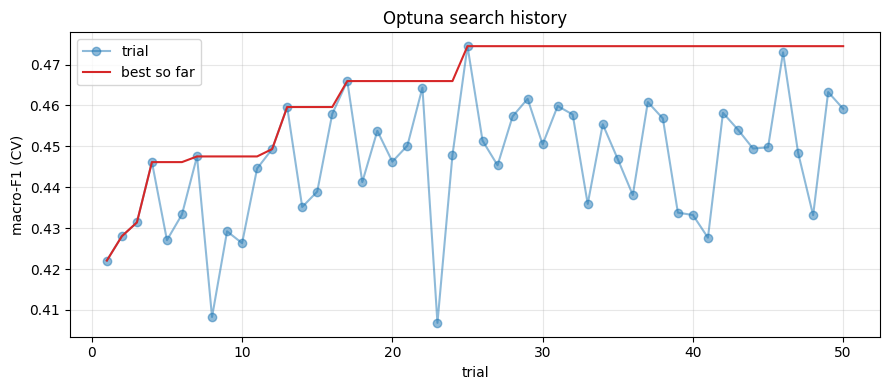

In [12]:
trial_vals = [t.value for t in study.trials if t.value is not None]
running_best = np.maximum.accumulate(trial_vals)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(1, len(trial_vals) + 1), trial_vals, "o-", alpha=0.5, label="trial")
ax.plot(range(1, len(running_best) + 1), running_best, "-", color="#d62728", label="best so far")
ax.set_xlabel("trial")
ax.set_ylabel("macro-F1 (CV)")
ax.set_title("Optuna search history")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "mlp_optuna_history.png", dpi=150)
plt.show()


# 8 Final fit with best Optuna params

In [13]:
final_params = {k: v for k, v in best_params.items() if k != "batch_size"}
best_batch_size = best_params["batch_size"]

final_train_loader = DataLoader(
    CrashDataset(cat_train_sm, num_train_sm, y_train_sm),
    batch_size=best_batch_size,
    shuffle=True,
)
final_val_loader = DataLoader(
    CrashDataset(cat_val, num_val, y_val),
    batch_size=best_batch_size,
    shuffle=False,
)
final_test_loader = DataLoader(
    CrashDataset(cat_test, num_test, y_test),
    batch_size=best_batch_size,
    shuffle=False,
)

log.info(f"Final fit with best params: {final_params}, batch_size={best_batch_size}")
final_model, final_val_f1, final_history = train_model(
    final_params,
    final_train_loader,
    final_val_loader,
    embedding_dims,
    n_num=len(num_cols),
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    verbose=True,
)
log.info(f"final best val_f1_macro: {final_val_f1:.4f}")


16:41:48 [INFO] Final fit with best params: {'hidden_dim': 501, 'n_layers': 4, 'dropout': 0.46264626283173266, 'lr': 0.004135858631134951, 'weight_decay': 0.0006917940107921995}, batch_size=256
16:41:49 [INFO] epoch 001 | loss=0.8044 | val_f1_macro=0.3746 | best=0.3746
16:41:49 [INFO] epoch 002 | loss=0.5739 | val_f1_macro=0.3856 | best=0.3856
16:41:50 [INFO] epoch 003 | loss=0.4899 | val_f1_macro=0.4262 | best=0.4262
16:41:50 [INFO] epoch 005 | loss=0.4168 | val_f1_macro=0.4160 | best=0.4262
16:41:50 [INFO] epoch 006 | loss=0.3962 | val_f1_macro=0.4314 | best=0.4314
16:41:52 [INFO] epoch 010 | loss=0.3545 | val_f1_macro=0.4178 | best=0.4314
16:41:53 [INFO] epoch 015 | loss=0.3169 | val_f1_macro=0.4397 | best=0.4397
16:41:54 [INFO] epoch 018 | loss=0.3029 | val_f1_macro=0.4657 | best=0.4657
16:41:55 [INFO] epoch 020 | loss=0.3066 | val_f1_macro=0.4209 | best=0.4657
16:41:56 [INFO] epoch 025 | loss=0.2847 | val_f1_macro=0.4378 | best=0.4657
16:41:58 [INFO] epoch 030 | loss=0.2697 | val_

In [ ]:
# Training curves - useful for diagnosing over/underfitting.
# Mirrors TabNet's training-curves layout. MLP's history records train_loss and
# val_f1_macro (no val_loss / train_accuracy), so the two subplots show those.
hist_epochs = [h["epoch"] for h in final_history]
hist_train_loss = [h["train_loss"] for h in final_history]
hist_val_f1 = [h["val_f1_macro"] for h in final_history]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_epochs, hist_train_loss, label="train", color="#1f77b4")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
axes[0].set_title("Training loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(hist_epochs, hist_val_f1, label="val", color="#d62728")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("macro-F1")
axes[1].set_title("Validation macro-F1"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "mlp_training_curves.png", dpi=150)
plt.show()


# 9 Test evaluation


=== Test set (argmax) ===
  accuracy           0.7922
  precision_macro    0.4368
  recall_macro       0.4265
  f1_macro           0.4301
  f1_weighted        0.7818
  roc_auc_ovr        0.6508

  classification report:
              precision    recall  f1-score   support

      Slight       0.87      0.90      0.88      1563
     Serious       0.28      0.21      0.24       261
       Fatal       0.17      0.17      0.17        24

    accuracy                           0.79      1848
   macro avg       0.44      0.43      0.43      1848
weighted avg       0.77      0.79      0.78      1848



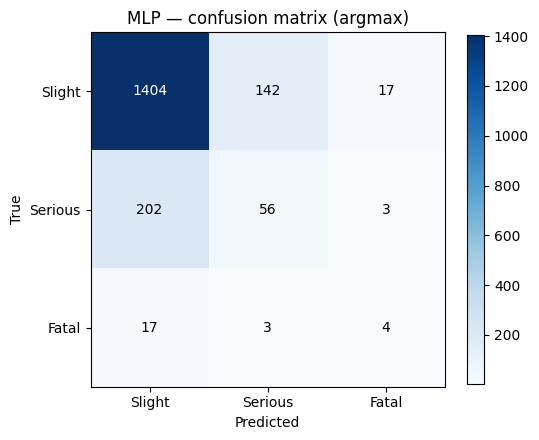

In [28]:
y_test_true, y_pred, y_proba = predict_proba(final_model, final_test_loader)

test_metrics = metric_block(
    y_test_true,
    y_pred,
    y_proba,
    label="Test set (argmax)",
)

cm = confusion_matrix(y_test_true, y_pred)
plot_confusion(
    cm,
    "MLP — confusion matrix (argmax)",
    save_path=FIG_DIR / "mlp_confusion_argmax.png",
)


# 10 Threshold tuning

Same per-class one-vs-rest threshold sweep as TabNet. This uses the already-computed test probabilities from the argmax cell.


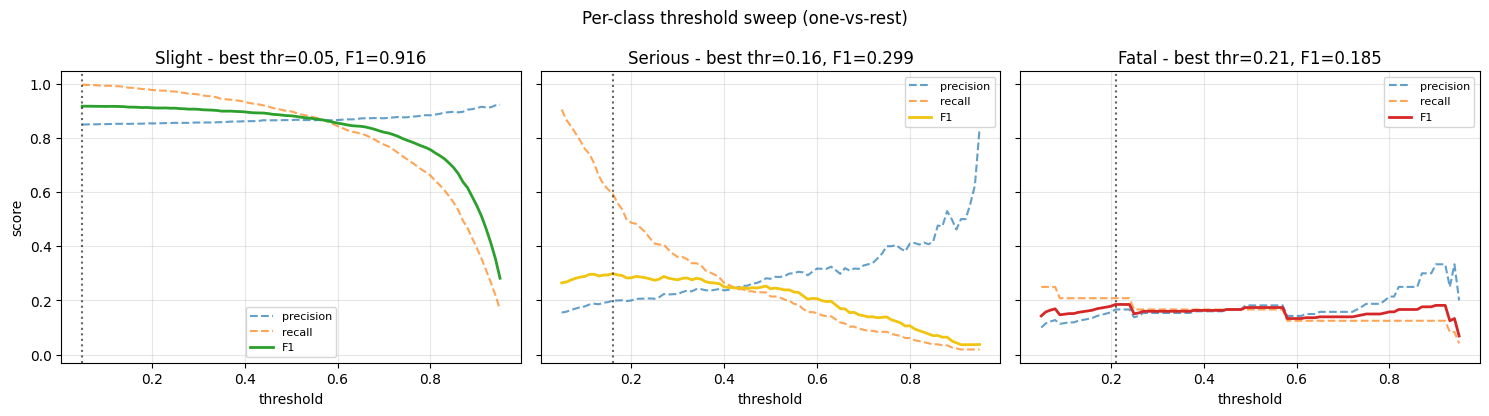

Best per-class thresholds: {'Slight': 0.05, 'Serious': 0.15999999999999998, 'Fatal': 0.20999999999999996}


In [15]:
thresholds = np.linspace(0.05, 0.95, 91)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
best_thr = {}

for k, (name, color) in enumerate(zip(SEV_SHORT, SEVERITY_PALETTE)):
    f1s, pres, recs = [], [], []
    y_bin = (y_test_true == k).astype(int)
    for thr in thresholds:
        p_bin = (y_proba[:, k] >= thr).astype(int)
        f1s.append(f1_score(y_bin, p_bin, zero_division=0))
        pres.append(precision_score(y_bin, p_bin, zero_division=0))
        recs.append(recall_score(y_bin, p_bin, zero_division=0))

    f1s = np.array(f1s)
    pres = np.array(pres)
    recs = np.array(recs)
    best_idx = int(np.argmax(f1s))
    best_thr[name] = float(thresholds[best_idx])

    ax = axes[k]
    ax.plot(thresholds, pres, label="precision", color="#1f77b4", linestyle="--", alpha=0.7)
    ax.plot(thresholds, recs, label="recall", color="#ff7f0e", linestyle="--", alpha=0.7)
    ax.plot(thresholds, f1s, label="F1", color=color, linewidth=2)
    ax.axvline(thresholds[best_idx], color="black", linestyle=":", alpha=0.6)
    ax.set_title(f"{name} - best thr={thresholds[best_idx]:.2f}, F1={f1s[best_idx]:.3f}")
    ax.set_xlabel("threshold")
    if k == 0:
        ax.set_ylabel("score")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle("Per-class threshold sweep (one-vs-rest)")
plt.tight_layout()
plt.savefig(FIG_DIR / "mlp_threshold_sweep.png", dpi=150)
plt.show()
print("Best per-class thresholds:", best_thr)


=== Test set (threshold-tuned) ===
  accuracy           0.7922
  precision_macro    0.4368
  recall_macro       0.4265
  f1_macro           0.4301
  f1_weighted        0.7818
  roc_auc_ovr        0.6508

  classification report:
              precision    recall  f1-score   support

      Slight       0.87      0.90      0.88      1563
     Serious       0.28      0.21      0.24       261
       Fatal       0.17      0.17      0.17        24

    accuracy                           0.79      1848
   macro avg       0.44      0.43      0.43      1848
weighted avg       0.77      0.79      0.78      1848



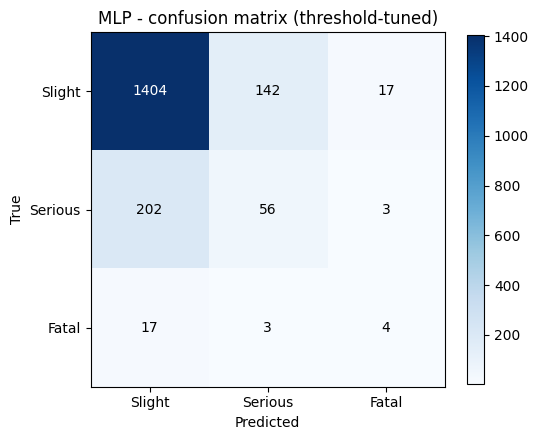

In [29]:
def predict_with_thresholds(proba, thr_map):
    """Apply per-class thresholds; fallback to argmax if no class passes."""
    thr_arr = np.array([thr_map[n] for n in SEV_SHORT])
    above = proba >= thr_arr
    out = np.full(len(proba), -1, dtype=int)
    for i in range(len(proba)):
        if above[i].any():
            cand = np.where(above[i])[0]
            out[i] = cand[np.argmax(proba[i, cand])]
        else:
            out[i] = int(np.argmax(proba[i]))
    return out


y_pred_tuned = predict_with_thresholds(y_proba, best_thr)
tuned_metrics = metric_block(
    y_test_true,
    y_pred_tuned,
    y_proba,
    label="Test set (threshold-tuned)",
)

cm_tuned = confusion_matrix(y_test_true, y_pred_tuned)
plot_confusion(
    cm_tuned,
    "MLP - confusion matrix (threshold-tuned)",
    save_path=FIG_DIR / "mlp_confusion_tuned.png",
)


# 11 Save metrics and artifacts


In [17]:
torch.save({
    "model_state_dict": final_model.state_dict(),
    "architecture": {
        "embedding_dims": embedding_dims,
        "n_num": len(num_cols),
        "hidden_dim": final_params["hidden_dim"],
        "n_layers": final_params["n_layers"],
        "dropout": final_params["dropout"],
    },
    "best_params": best_params,
    "best_batch_size": best_batch_size,
    "best_thresholds": best_thr,
    "final_val_f1_macro": final_val_f1,
    "final_history": final_history,
}, MODEL_DIR / "mlp_best.pt")

joblib.dump({
    "encoder": encoder,
    "scaler": scaler,
    "cat_cols": cat_cols,
    "num_cols": num_cols,
    "feature_names": feature_names,
    "embedding_dims": embedding_dims,
    "best_params": best_params,
    "best_batch_size": best_batch_size,
    "best_thresholds": best_thr,
}, MODEL_DIR / "mlp_artifacts.joblib")

results = {
    "best_params": best_params,
    "best_thresholds": best_thr,
    "test_argmax": test_metrics,
    "test_threshold_tuned": tuned_metrics,
    "confusion_argmax": cm.tolist(),
    "confusion_tuned": cm_tuned.tolist(),
    "n_train": int(len(y_train)),
    "n_val": int(len(y_val)),
    "n_test": int(len(y_test)),
}
RESULTS.write_text(json.dumps(results, indent=2))
log.info(f"Saved model to {MODEL_DIR / 'mlp_best.pt'}")
log.info(f"Saved artifacts to {MODEL_DIR / 'mlp_artifacts.joblib'}")
log.info(f"Wrote {RESULTS}")


16:46:33 [INFO] Saved model to /home/minhubuntu/projects/crash-severity-tabnet-stacking/models/mlp_best.pt
16:46:33 [INFO] Saved artifacts to /home/minhubuntu/projects/crash-severity-tabnet-stacking/models/mlp_artifacts.joblib
16:46:33 [INFO] Wrote /home/minhubuntu/projects/crash-severity-tabnet-stacking/outputs/mlp_metrics.json


# 12 SHAP interpretation

KernelExplainer uses 100 train samples as background and 200 test samples for evaluation. The wrapper accepts the combined encoded matrix `[categorical indices + scaled numeric features]` and converts categorical values back to valid embedding indices.


In [18]:
def predict_from_combined_matrix(X):
    """Predict probabilities from combined [cat indices + scaled numeric] matrix."""
    X = np.asarray(X)
    n_cat = len(cat_cols)
    X_cat = np.rint(X[:, :n_cat]).astype(np.int64)
    X_num = X[:, n_cat:].astype(np.float32)

    for j, (cardinality, _) in enumerate(embedding_dims):
        X_cat[:, j] = np.clip(X_cat[:, j], 0, cardinality - 1)

    loader = DataLoader(
        CrashDataset(X_cat, X_num, np.zeros(len(X_cat), dtype=np.int64)),
        batch_size=best_batch_size,
        shuffle=False,
    )
    _, _, proba = predict_proba(final_model, loader)
    return proba


rng = np.random.default_rng(SEED)
X_train_shap = np.concatenate([cat_train_sm, num_train_sm], axis=1).astype(np.float32)
X_test_shap = np.concatenate([cat_test, num_test], axis=1).astype(np.float32)
feature_names = cat_cols + num_cols

bg_idx = rng.choice(len(X_train_shap), size=min(SHAP_BG, len(X_train_shap)), replace=False)
background = X_train_shap[bg_idx]

eval_idx = rng.choice(len(X_test_shap), size=min(SHAP_EVAL, len(X_test_shap)), replace=False)
X_shap = X_test_shap[eval_idx]

log.info(f"SHAP: background={len(background)}, eval={len(X_shap)}")
explainer = shap.KernelExplainer(predict_from_combined_matrix, background)
t0 = time.time()
shap_values = explainer.shap_values(X_shap, nsamples=100)
log.info(f"SHAP done in {time.time() - t0:.1f}s; shape={np.array(shap_values).shape}")


16:46:38 [INFO] SHAP: background=100, eval=200
100%|██████████| 200/200 [00:17<00:00, 11.47it/s]
16:46:55 [INFO] SHAP done in 17.4s; shape=(200, 26, 3)


/tmp/ipykernel_89862/1663251185.py:8: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_per_class, X_shap, feature_names=feature_names,


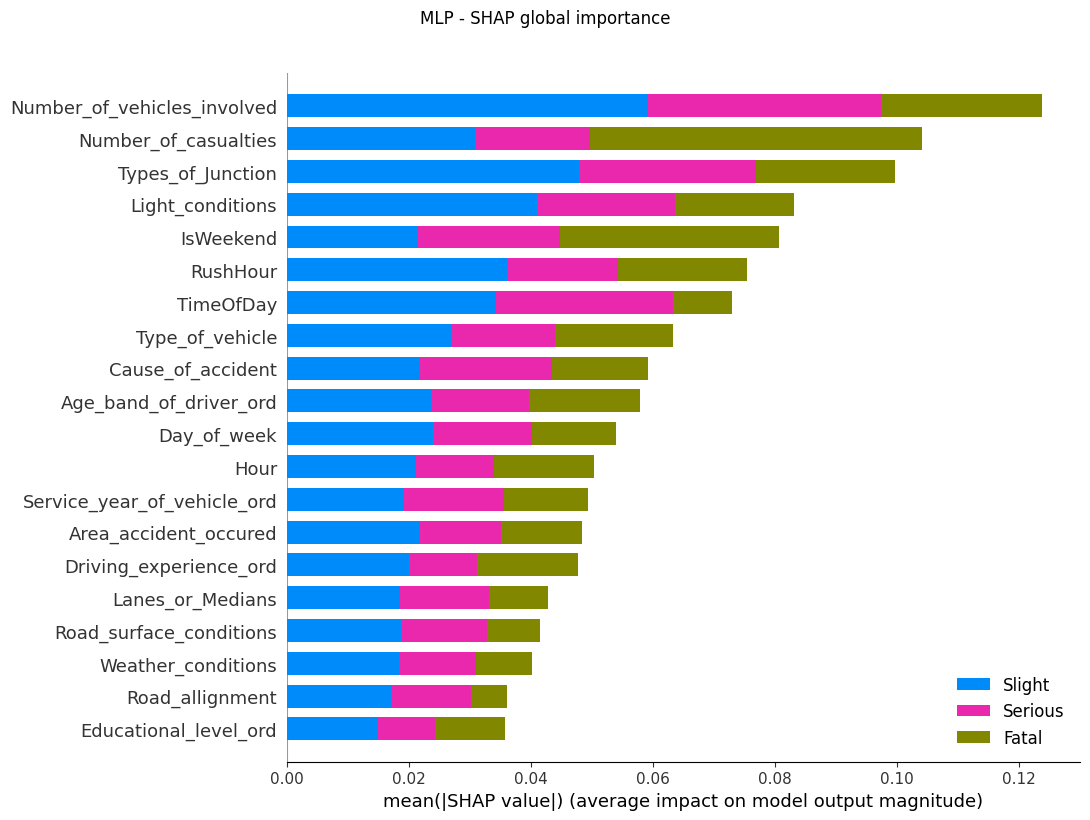

In [22]:
# Summary plot (bar) - global feature importance across all classes.
# Convert (N, F, C) -> list of (N, F) per class for shap.summary_plot.
if isinstance(shap_values, list):
    shap_per_class = shap_values
else:
    shap_per_class = [shap_values[:, :, k] for k in range(3)]

shap.summary_plot(shap_per_class, X_shap, feature_names=feature_names,
                  plot_type="bar", class_names=SEV_SHORT, show=False, plot_size=(11, 8))
fig = plt.gcf(); fig.suptitle("MLP - SHAP global importance", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "mlp_shap_summary_bar.png", dpi=150, bbox_inches="tight")
plt.show()


/tmp/ipykernel_89862/3502192949.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_per_class[fatal_idx], X_shap, feature_names=feature_names,


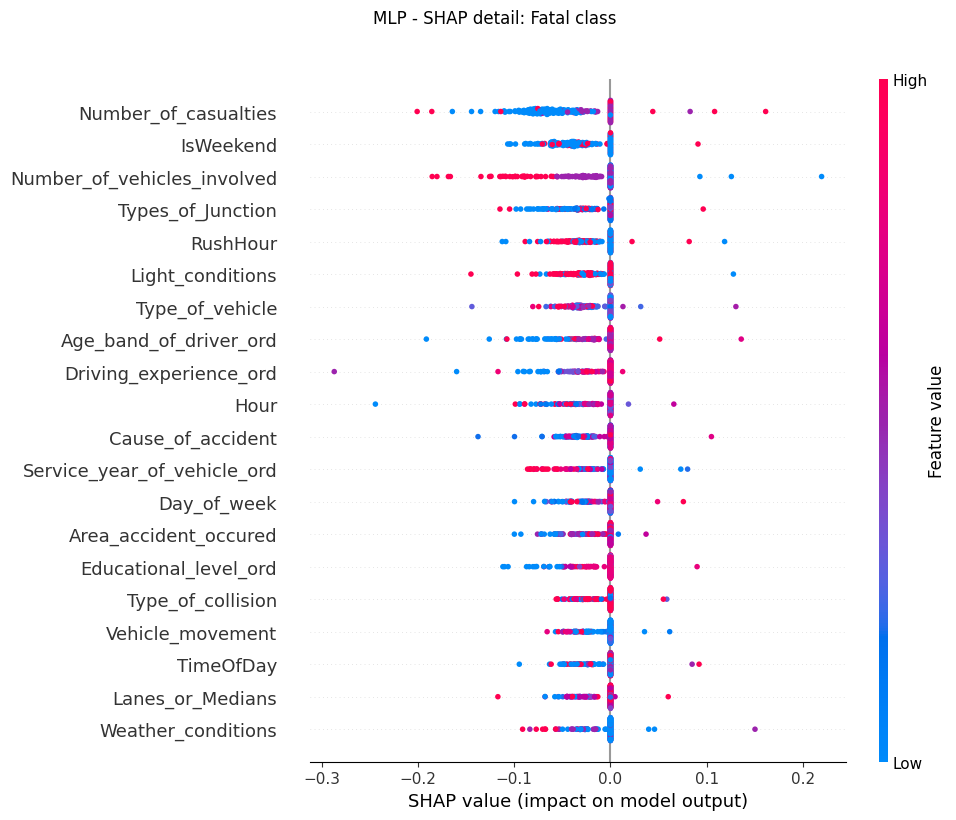

In [23]:
# Dot plot for the Fatal class - where the model concentrates its risk signal.
fatal_idx = SEV_SHORT.index("Fatal")
shap.summary_plot(shap_per_class[fatal_idx], X_shap, feature_names=feature_names,
                  plot_type="dot", show=False, plot_size=(10, 8))
fig = plt.gcf(); fig.suptitle("MLP - SHAP detail: Fatal class", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "mlp_shap_dot_fatal.png", dpi=150, bbox_inches="tight")
plt.show()


# 13 Post-hoc / sensitivity analysis

Same intervention as the TabNet notebook: set `Light_conditions` to 'Daylight' across the test set and compare the mean predicted probabilities.


Mean predicted probability shift after setting Light_conditions='Daylight':
  Slight   original=0.7772  intervened=0.7754  delta=-0.0018
  Serious  original=0.2070  intervened=0.2100  delta=+0.0030
  Fatal    original=0.0158  intervened=0.0146  delta=-0.0012


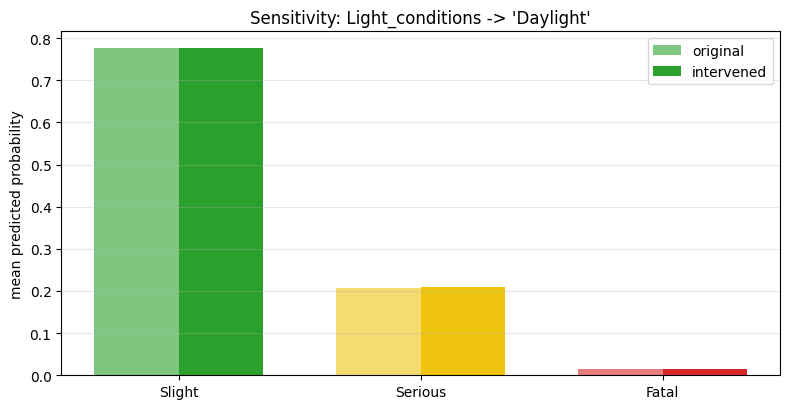

In [21]:
target_feature = "Light_conditions"
intervene_value = "Daylight"

if intervene_value not in df["Light_conditions"].unique():
    intervene_value = df["Light_conditions"].mode().iloc[0]
    log.info(f"'Daylight' not in data; intervening with '{intervene_value}' instead")

df_test_int = df_test.copy()
df_test_int[target_feature] = intervene_value
cat_test_int, num_test_int, _, _ = encode_mlp(
    df_test_int, cat_cols, num_cols, encoder=encoder, scaler=scaler, fit=False
)
int_loader = DataLoader(
    CrashDataset(cat_test_int, num_test_int, y_test),
    batch_size=best_batch_size,
    shuffle=False,
)
_, _, proba_int = predict_proba(final_model, int_loader)

orig_mean = y_proba.mean(axis=0)
intv_mean = proba_int.mean(axis=0)
delta = intv_mean - orig_mean

print(f"Mean predicted probability shift after setting {target_feature}='{intervene_value}':")
for name, o, i, d in zip(SEV_SHORT, orig_mean, intv_mean, delta):
    print(f"  {name:<8s} original={o:.4f}  intervened={i:.4f}  delta={d:+.4f}")

fig, ax = plt.subplots(figsize=(8, 4.2))
x = np.arange(3); w = 0.35
ax.bar(x - w/2, orig_mean, width=w, color=SEVERITY_PALETTE, label="original", alpha=0.6)
ax.bar(x + w/2, intv_mean, width=w, color=SEVERITY_PALETTE, label="intervened", alpha=1.0)
ax.set_xticks(x); ax.set_xticklabels(SEV_SHORT)
ax.set_ylabel("mean predicted probability")
ax.set_title(f"Sensitivity: {target_feature} -> '{intervene_value}'")
ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG_DIR / "mlp_sensitivity_light.png", dpi=150)
plt.show()


# 14 Summary

- Best Optuna macro-F1 (CV): see log above.
- Argmax test metrics: standard highest-probability prediction.
- Threshold-tuned test metrics: same per-class threshold sweep as TabNet and Stacking.
- Saved artifacts: models/mlp_best.pt, models/mlp_artifacts.joblib, outputs/mlp_metrics.json, and figures under outputs/figures/.
- Interpretation outputs: SHAP global importance, SHAP Fatal-class detail, and Light_conditions sensitivity analysis.

This MLP pipeline uses the same data source, feature contract, train/validation/test split, SMOTE rule, Macro-F1 objective, metrics structure, threshold-tuning approach, SHAP setup, and sensitivity scenario as the TabNet and Stacking notebooks. The model-specific difference is the MLP entity-embedding path for categorical features before concatenating scaled numeric features.
